# Linear Regression

In [ ]:
'''
- y=mX + C

y -> Predict Data
m -> Slope / Coefficient [Each feature value has different slope]
X -> Data Point
C -> intercept [Constant]
'''

# Real State House Price Prediction using Regression Models

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Linear Regression Model
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
# Random Forest Model
from sklearn.ensemble import RandomForestRegressor
# Train Test Split
from sklearn.model_selection import train_test_split, KFold, cross_val_score
# Feature Scaling
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
# Import Pipeline
from sklearn.pipeline import Pipeline
# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('Dataset/Real estate.csv')
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


## Data Cleaning

In [3]:
# Remove unwanted columns
df = df.drop(columns = ['No', 'X1 transaction date'])

In [4]:
df.isnull().sum()

X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 6 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X2 house age                            414 non-null    float64
 1   X3 distance to the nearest MRT station  414 non-null    float64
 2   X4 number of convenience stores         414 non-null    int64  
 3   X5 latitude                             414 non-null    float64
 4   X6 longitude                            414 non-null    float64
 5   Y house price of unit area              414 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 19.5 KB


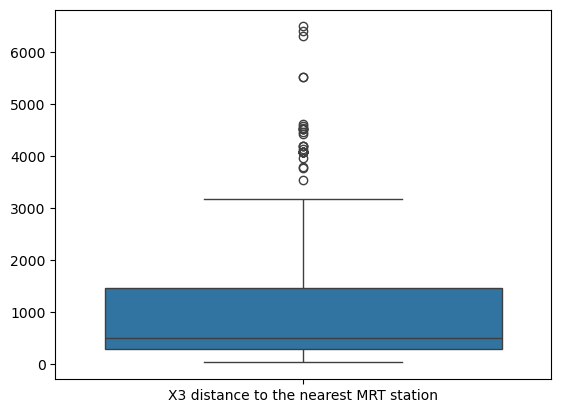

In [6]:
## Box Plot for detecting outliers
sns.boxplot(df[['X3 distance to the nearest MRT station']])
plt.show()

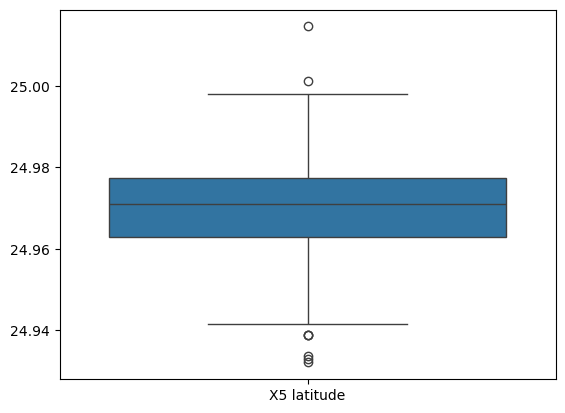

In [7]:
sns.boxplot(df[['X5 latitude']])
plt.show()

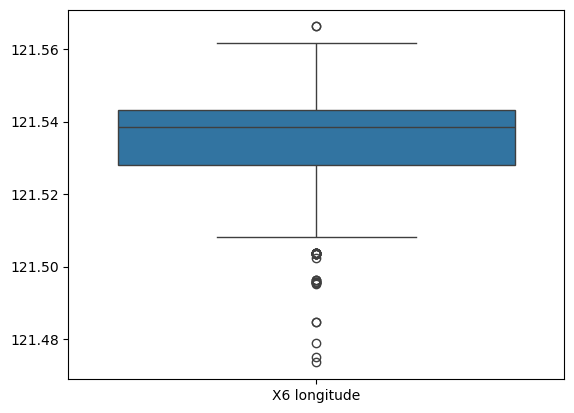

In [8]:
sns.boxplot(df[['X6 longitude']])
plt.show()

## Feature and Target

In [9]:
feature = ['X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 
           'X5 latitude', 'X6 longitude']
target = 'Y house price of unit area'

In [10]:
X = df[feature]
Y = df[target]

<Axes: >

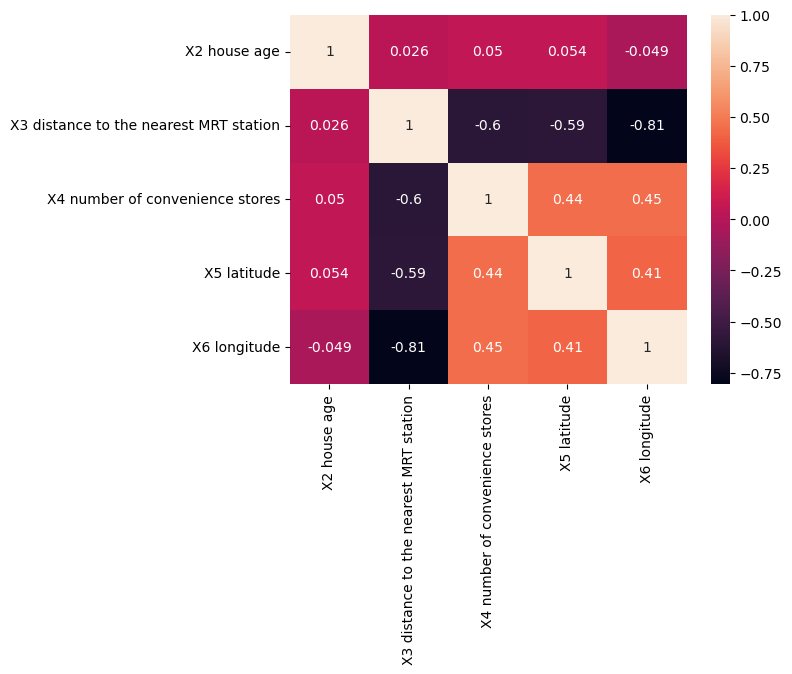

In [11]:
corr_data = X.corr()
sns.heatmap(corr_data, annot=True)

## Train Test Split

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

## Feature Scaling

In [ ]:
'''
    (Xi - Mean) / SD
    
    Feature Training -> fit_transform()
        - Fit -> Learning -> Calculates Mean and SD
        - Transform -> Implement -> Implements Formula into data
    
    
    Feature Testing -> transform()
        - Transform -> Implement -> Implements Training Learning data
'''

In [13]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

## Adjusting R2 Score Function

In [14]:
def adjustR2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

n_sample = X_test.shape[0]
p = X_train.shape[1]

## Model Implementation

In [15]:
model = LinearRegression()
# Train model
model.fit(X_train_scale, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
Y_pred = model.predict(X_test_scale)

## Calculate Intercept and Slope/Coefficient of Model

In [17]:
beta_0 = model.intercept_
beta_1 = model.coef_

print(f'Intercept (Beta 0): {beta_0}')
print(f'Coefficient / Slope (Beta 1): {beta_1}')

Intercept (Beta 0): 38.39154078549814
Coefficient / Slope (Beta 1): [-3.06045213 -5.53623761  3.25926406  2.94298597 -0.35743672]


## Metrics

In [ ]:
'''
- Y_test -> Actual Data (X-axis)
- Y_pred -> Predicted Data (Y-axis)
'''

In [18]:
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)
adjust_r2 = adjustR2(r2, n_sample, p)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE / Loss Function): {rmse}')
print(f'R2 Score (Residual Score / Cost Function): {r2}')
print(f'Adjusted R2 Score: {adjust_r2}')

Mean Absolute Error (MAE): 5.350138374356212
Mean Squared Error (MSE): 54.580945200862146
Root Mean Squared Error (RMSE / Loss Function): 7.3878917967754605
R2 Score (Residual Score / Cost Function): 0.6746481382828176
Adjusted R2 Score: 0.653521394015468


## Visualization

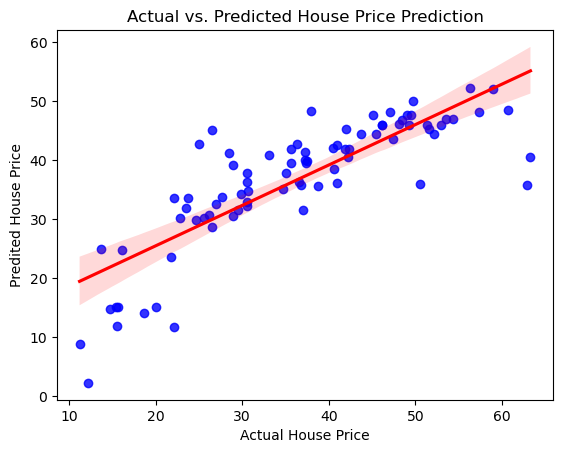

In [19]:
# regression plot
sns.regplot(x=Y_test, y=Y_pred, color='blue', line_kws={'color': 'red'})
plt.xlabel('Actual House Price')
plt.ylabel('Predited House Price')
plt.title('Actual vs. Predicted House Price Prediction')
plt.show()

In [ ]:
'''
1. Cross Validation

2. Regularization
    i. Polynomial Regression
        -> To work with non-linear feature pattern data
        -> x1, x2, x3
        -> X1^2, X2^2
        -> X1X2

        -> X1^2, X3^2
        -> X1X3
        
    ii. Ridge Regression
        -> If required to make weight near 0 to reduce biasness between features.
        -> alpha -> 1.0
        
    iii. Lasso Regression
        -> If required to remove feature execution from model making unwanted feature weight to 0.
        -> alpha -> 0.1
        
    iv. ElasticNet Regression
        -> Combination of both Ridge Regression and Lasso Regression
        -> alpha = 0.1, l1_ratio = 0.5
        
3. Adjusting R2 Score
    -> 1 - ((1 - r2) * (n - 1)) / (n - p - 1)
    -> n -> number of test samples (X_test.shape)
    -> p -> number of features (X_train.shape)
    -> r2 -> Residual Score
'''

## Cross Validation

In [20]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42) # train data -> 5 times
cv_score = cross_val_score(model, scaler.fit_transform(X), Y, scoring='r2')

print(f'Cross Validation Scores: {cv_score}')
print(f'Average Cross Validation Score: {cv_score.mean()}')

Cross Validation Scores: [0.68463546 0.53209757 0.66649314 0.42112676 0.57912236]
Average Cross Validation Score: 0.5766950593066446


## Polynomial Regression

In [21]:
poly = Pipeline([
    # Feature Scaling
    ('scaler', StandardScaler()),
    # Check for non linear feature pattern
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    # check from the model
    ('liner', LinearRegression())
])
poly.fit(X_train, Y_train)
poly_predict = poly.predict(X_test)

poly_mae = mean_absolute_error(Y_test, poly_predict)
poly_mse = mean_squared_error(Y_test, poly_predict)
poly_rmse = np.sqrt(poly_mse)
poly_r2 = r2_score(Y_test, poly_predict)
poly_adjust_r2 = adjustR2(poly_r2, n_sample, p)

print(f'Mean Absolute Error (MAE): {poly_mae}')
print(f'Mean Squared Error (MSE): {poly_mse}')
print(f'Root Mean Squared Error (RMSE / Loss Function): {poly_rmse}')
print(f'R2 Score (Residual Score / Cost Function): {poly_r2}')
print(f'Adjusted R2 Score: {poly_adjust_r2}')

Mean Absolute Error (MAE): 4.812176820584436
Mean Squared Error (MSE): 41.850482438547104
Root Mean Squared Error (RMSE / Loss Function): 6.4691948833334045
R2 Score (Residual Score / Cost Function): 0.7505332250103929
Adjusted R2 Score: 0.7343340837773016


## Ridge Regression

In [22]:
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
ridge.fit(X_train, Y_train)
ridge_pred = ridge.predict(X_test)

ridge_r2 = r2_score(Y_test, ridge_pred)
print(f'Ridge R2 Score: {ridge_r2}')

Ridge R2 Score: 0.6749144123534498


## Lasso Regression

In [23]:
lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.1))
])
lasso.fit(X_train, Y_train)
lasso_pred = lasso.predict(X_test)

lasso_r2 = r2_score(Y_test, lasso_pred)
print(f'Ridge R2 Score: {lasso_r2}')

Ridge R2 Score: 0.6761322962813272


## ElasticNet Regression

In [24]:
en = Pipeline([
    ('scaler', StandardScaler()),
    ('en', ElasticNet(alpha=0.1, l1_ratio=0.5))
])
en.fit(X_train, Y_train)
en_pred = en.predict(X_test)

en_r2 = r2_score(Y_test, en_pred)
print(f'Ridge R2 Score: {en_r2}')

Ridge R2 Score: 0.6766485702514125


## Random Forest Regressor

In [44]:
rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf_poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('rf_regressor', RandomForestRegressor())
])
rf.fit(X_train, Y_train)
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(Y_test, rf_pred)
rf_mse = mean_squared_error(Y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(Y_test, rf_pred)

print(f'Mean Absolute Error (MAE): {rf_mae}')
print(f'Mean Squared Error (MSE): {rf_mse}')
print(f'Root Mean Squared Error (RMSE / Loss Function): {rf_rmse}')
print(f'R2 Score (Residual Score / Cost Function): {rf_r2}')

Mean Absolute Error (MAE): 4.15238875502008
Mean Squared Error (MSE): 31.454652182023334
Root Mean Squared Error (RMSE / Loss Function): 5.608444720421459
R2 Score (Residual Score / Cost Function): 0.8125017877681224


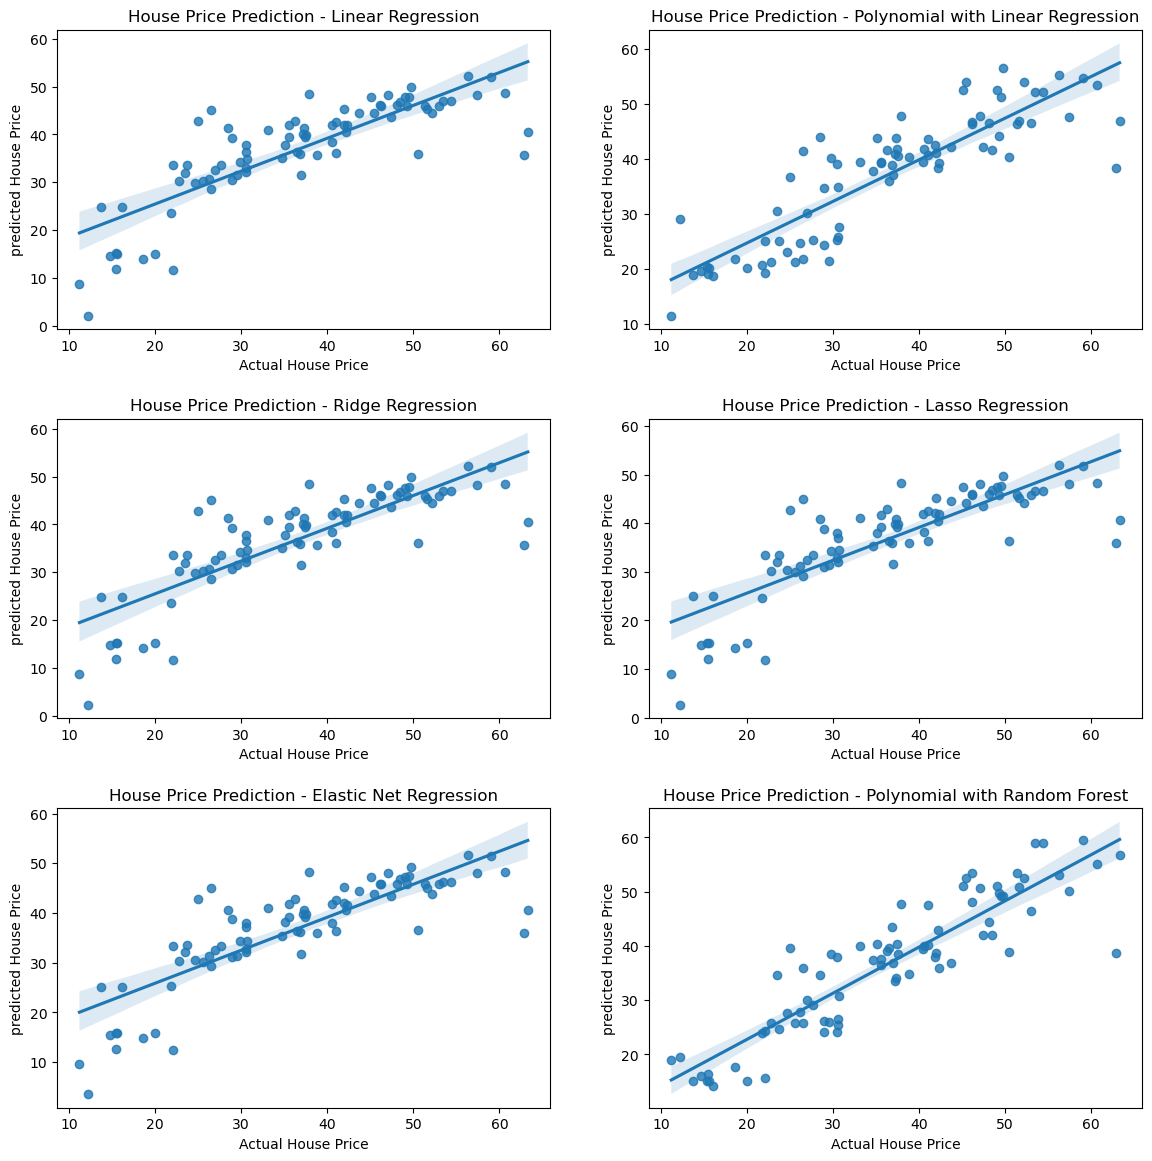

In [67]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
plt.subplots_adjust(hspace=0.3)

sns.regplot(x=Y_test, y=Y_pred, ax=axes[0, 0])
axes[0, 0].set_title('House Price Prediction - Linear Regression')
axes[0, 0].set_xlabel('Actual House Price')
axes[0, 0].set_ylabel('predicted House Price')

sns.regplot(x=Y_test, y=poly_predict, ax=axes[0, 1])
axes[0, 1].set_title('House Price Prediction - Polynomial with Linear Regression')
axes[0, 1].set_xlabel('Actual House Price')
axes[0, 1].set_ylabel('predicted House Price')

sns.regplot(x=Y_test, y=ridge_pred, ax=axes[1, 0])
axes[1, 0].set_title('House Price Prediction - Ridge Regression')
axes[1, 0].set_xlabel('Actual House Price')
axes[1, 0].set_ylabel('predicted House Price')

sns.regplot(x=Y_test, y=lasso_pred, ax=axes[1, 1])
axes[1, 1].set_title('House Price Prediction - Lasso Regression')
axes[1, 1].set_xlabel('Actual House Price')
axes[1, 1].set_ylabel('predicted House Price')

sns.regplot(x=Y_test, y=en_pred, ax=axes[2, 0])
axes[2, 0].set_title('House Price Prediction - Elastic Net Regression')
axes[2, 0].set_xlabel('Actual House Price')
axes[2, 0].set_ylabel('predicted House Price')

sns.regplot(x=Y_test, y=rf_pred, ax=axes[2, 1])
axes[2, 1].set_title('House Price Prediction - Polynomial with Random Forest')
axes[2, 1].set_xlabel('Actual House Price')
axes[2, 1].set_ylabel('predicted House Price')

plt.show()